# Multi-Datensatz Vergleich — Graphtec GL840
Mehrere CSV-Dateien übereinanderlegen, zeitlich verschieben und Kanäle ein-/ausblenden.

In [16]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import ipywidgets as widgets
from IPython.display import display
import glob
import os
from pathlib import Path
import ipympl  # installiert durch pip, ermöglicht %matplotlib widget
%matplotlib widget



## Konfiguration

In [17]:
# ──────────────────────────────────────────────
# Konfiguration — hier anpassen
# ──────────────────────────────────────────────

# Pfad zu den CSV-Dateien (Glob-Pattern oder Liste von Pfaden)
CSV_PATTERN = 'data/20min/*.CSV'   # z.B. alle CSV im data-Ordner
# Alternativ: explizite Liste
# CSV_FILES = ['data/260203-084845.CSV', 'data/260220-154821.CSV']

# NTC-Parameter (für CH10, falls vorhanden)
V_SUPPLY = 3.3
R_FIX    = 20_000
R0       = 47_000
B_CONST  = 4050
T0_K     = 298.15

# Anzahl Skip-Zeilen im CSV-Header (Standard Graphtec GL840: 33)
SKIPROWS = 33

## Hilfsfunktionen

In [18]:
def ntc_voltage_to_celsius(v_res, v_supply=V_SUPPLY, r_fix=R_FIX,
                            r0=R0, b=B_CONST, t0_k=T0_K):
    """Spannung über NTC (Spannungsteiler) → Temperatur in °C."""
    v_ntc    = v_supply - v_res
    r_ntc    = (v_ntc * r_fix) / (v_supply - v_ntc)
    t_kelvin = 1.0 / (1.0 / t0_k + np.log(r_ntc / r0) / b)
    return t_kelvin - 273.15


def detect_skiprows(path):
    """Findet die Zeile mit 'Number,Date&Time' automatisch."""
    with open(path, encoding='utf-8', errors='replace') as f:
        for i, line in enumerate(f):
            if 'Number' in line and 'Date' in line:
                return i  # diese Zeile = Header → skiprows = i
    return SKIPROWS  # Fallback


def read_graphtec_csv(path, convert_ntc_ch10=True):
    """
    Liest eine Graphtec GL840 CSV-Datei.
    Gibt DataFrame zurück mit:
      - 'datetime': Zeitstempel (inklusive ms)
      - 'elapsed_s': Sekunden seit Messbeginn
      - eine Spalte pro Messkanal (z.B. CH1, CH2, CH15 ...)
    """
    skip = detect_skiprows(path)
    
    # Rohdaten lesen
    raw = pd.read_csv(path, skiprows=skip, header=0, 
                      sep=',', engine='python', 
                      skipinitialspace=True, dtype=str,
                      on_bad_lines='skip')
    
    # Spaltennamen bereinigen
    raw.columns = [c.strip() for c in raw.columns]
    
    # Erste Zeile (Einheiten-Zeile) entfernen falls vorhanden
    if raw.iloc[0].astype(str).str.contains('deg|NO\.|ms', regex=True).any():
        raw = raw.iloc[1:].reset_index(drop=True)
    
    # Datum + ms kombinieren
    time_col = next((c for c in raw.columns if 'Time' in c or 'time' in c), None)
    ms_col   = next((c for c in raw.columns if raw.columns.tolist().index(c) == 2
                     and c.lower() in ('ms', '')), None)
    
    # Fallback: Spaltenposition
    cols = raw.columns.tolist()
    
    # Datetime aus Spalte 1 (0-basiert), ms aus Spalte 2
    dt_str = raw.iloc[:, 1].astype(str).str.strip()
    ms_str = raw.iloc[:, 2].astype(str).str.strip().str.replace(r'\s+', '', regex=True)
    ms_num = pd.to_numeric(ms_str, errors='coerce').fillna(0).astype(int)
    
    dt = pd.to_datetime(dt_str, format='%Y/%m/%d %H:%M:%S', errors='coerce')
    dt = dt + pd.to_timedelta(ms_num, unit='ms')
    
    # CH-Spalten identifizieren (alles was mit CH anfängt)
    ch_cols = [c for c in cols if c.upper().startswith('CH')]
    
    df = raw[ch_cols].copy()
    df.insert(0, 'datetime', dt)
    
    # CH-Werte bereinigen und numerisch konvertieren
    for c in ch_cols:
        df[c] = (df[c].astype(str)
                     .str.replace(r'[+\s]', '', regex=True)
                     .str.replace(',', '.', regex=False))
        df[c] = pd.to_numeric(df[c], errors='coerce')
    
    # CH10: NTC → °C
    if convert_ntc_ch10 and 'CH10' in df.columns:
        raw_v = df['CH10'].where(lambda x: (x > 0) & (x < V_SUPPLY))
        df['CH10'] = ntc_voltage_to_celsius(raw_v)
    
    # Ungültige Zeiten entfernen und sortieren
    df = df.dropna(subset=['datetime']).sort_values('datetime').reset_index(drop=True)
    
    # Elapsed time in Sekunden (für X-Achsen-Verschiebung)
    df['elapsed_s'] = (df['datetime'] - df['datetime'].iloc[0]).dt.total_seconds()
    
    return df, ch_cols


def load_all_datasets(pattern_or_list):
    """
    Lädt alle CSV-Dateien und gibt Liste von Dicts zurück:
      [{'name': str, 'df': DataFrame, 'ch_cols': list}, ...]
    """
    if isinstance(pattern_or_list, str):
        files = sorted(glob.glob(pattern_or_list))
    else:
        files = pattern_or_list
    
    if not files:
        print(f'⚠️  Keine Dateien gefunden: {pattern_or_list}')
        return []
    
    datasets = []
    for f in files:
        try:
            df, ch_cols = read_graphtec_csv(f)
            name = Path(f).stem
            datasets.append({'name': name, 'df': df, 'ch_cols': ch_cols})
            print(f'✓ {name}: {len(df)} Zeilen, Kanäle: {ch_cols}')
        except Exception as e:
            print(f'✗ Fehler bei {f}: {e}')
    
    return datasets

print('Hilfsfunktionen geladen.')

Hilfsfunktionen geladen.


## Datensätze laden

In [19]:
# Hier Dateien angeben — Pattern oder Liste:
datasets = load_all_datasets(CSV_PATTERN)
# datasets = load_all_datasets(['data/260203-084845.CSV', 'data/260220-154821.CSV'])

print(f'\n{len(datasets)} Datensatz/Datensätze geladen.')

✓ Mittel: 4836 Zeilen, Kanäle: ['CH1', 'CH2', 'CH3', 'CH4', 'CH12', 'CH13', 'CH14', 'CH15', 'CH16', 'CH17', 'CH18', 'CH19', 'CH20']
✓ Verguss: 4835 Zeilen, Kanäle: ['CH1', 'CH2', 'CH3', 'CH4', 'CH12', 'CH13', 'CH14', 'CH15', 'CH16', 'CH17', 'CH18', 'CH19', 'CH20']

2 Datensatz/Datensätze geladen.


## Interaktiver Multi-Datensatz-Vergleich

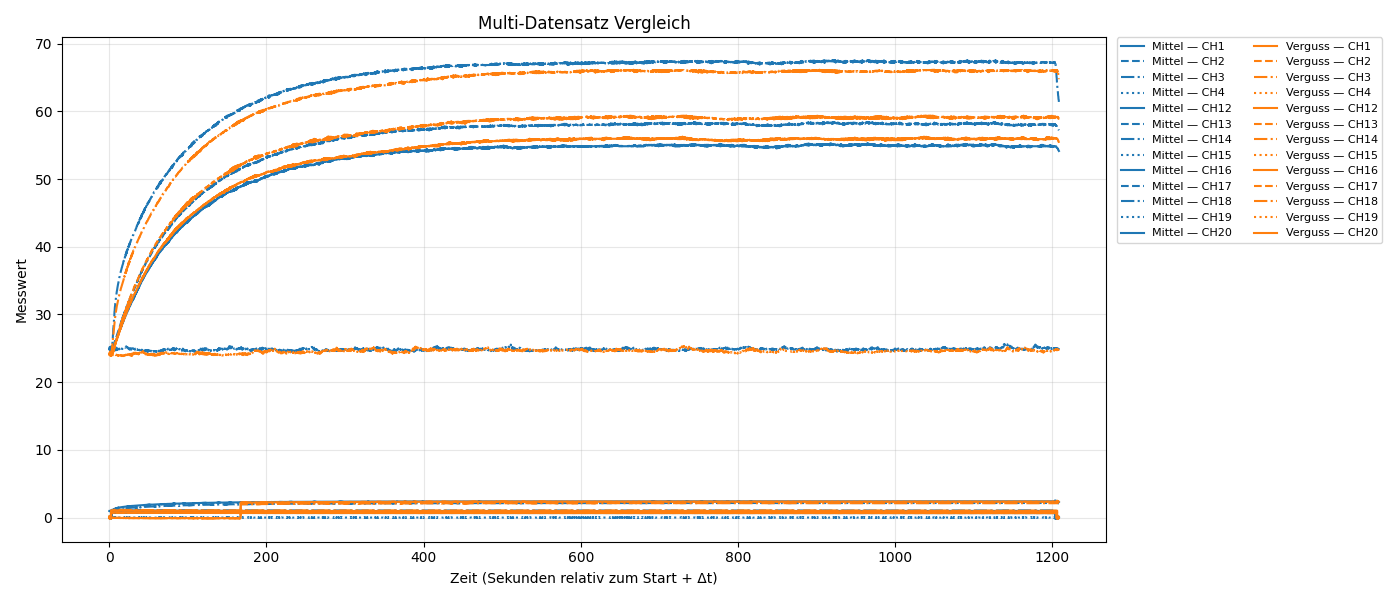

In [20]:
# Farben pro Datensatz (Kanäle desselben Datensatzes = gleiche Farbe, unterschiedliche Linienart)
DATASET_COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']
LINE_STYLES    = ['-', '--', '-.', ':']


def build_multi_compare_ui(datasets):
    if not datasets:
        print('Keine Datensätze vorhanden.')
        return
    
    # ── Alle vorhandenen Kanäle ermitteln ──
    all_channels = sorted(
        set(ch for ds in datasets for ch in ds['ch_cols']),
        key=lambda x: int(x.replace('CH', ''))
    )

    # ── Widget-Erstellung ──────────────────
    
    # Kanal-Checkboxen (gemeinsam für alle Datensätze)
    ch_checks = {ch: widgets.Checkbox(
        value=True, description=ch,
        layout=widgets.Layout(width='80px')
    ) for ch in all_channels}
    
    # Pro Datensatz: Aktivierungs-Toggle + Zeitverschiebungs-Slider
    ds_active  = {}
    ds_sliders = {}
    
    for i, ds in enumerate(datasets):
        color = DATASET_COLORS[i % len(DATASET_COLORS)]
        ds_active[ds['name']] = widgets.ToggleButton(
            value=True,
            description=ds['name'],
            button_style='',
            layout=widgets.Layout(width='220px'),
            style={'button_color': color, 'font_weight': 'bold'}
        )
        # Slider: ±Hälfte der Gesamtdauer des längsten Datensatzes
        max_dur = max(d['df']['elapsed_s'].max() for d in datasets)
        ds_sliders[ds['name']] = widgets.FloatSlider(
            value=0.0, min=-max_dur, max=max_dur,
            step=1.0,
            description='Δt (s):',
            continuous_update=True,
            layout=widgets.Layout(width='450px'),
            style={'description_width': '60px'}
        )
    
    # Y-Achse: Auto oder manuell
    y_auto = widgets.Checkbox(value=True, description='Y-Auto')
    y_min  = widgets.FloatText(value=0.0,   description='Y-Min:', layout=widgets.Layout(width='150px'))
    y_max  = widgets.FloatText(value=300.0, description='Y-Max:', layout=widgets.Layout(width='150px'))
    
    # ── Layout aufbauen ───────────────────
    
    # Schnellauswahl-Buttons
    btn_all    = widgets.Button(description='Alle', button_style='info',  layout=widgets.Layout(width='100px'))
    btn_ch1_3  = widgets.Button(description='Nur CH1–CH3', button_style='warning', layout=widgets.Layout(width='120px'))
    btn_none   = widgets.Button(description='Keine', button_style='danger', layout=widgets.Layout(width='100px'))

    def set_all(b):
        for cb in ch_checks.values(): cb.value = True
    def set_ch1_3(b):
        for ch, cb in ch_checks.items(): cb.value = ch in ('CH1', 'CH2', 'CH3')
    def set_none(b):
        for cb in ch_checks.values(): cb.value = False

    btn_all.on_click(set_all)
    btn_ch1_3.on_click(set_ch1_3)
    btn_none.on_click(set_none)

    header = widgets.HTML('<b>Kanäle anzeigen:</b>')
    quick_row = widgets.HBox([btn_all, btn_ch1_3, btn_none],
                              layout=widgets.Layout(margin='4px 0'))
    ch_box = widgets.HBox(list(ch_checks.values()), 
                          layout=widgets.Layout(flex_wrap='wrap'))
    
    ds_rows = []
    for ds in datasets:
        row = widgets.HBox([
            ds_active[ds['name']],
            ds_sliders[ds['name']]
        ])
        ds_rows.append(row)
    
    y_row = widgets.HBox([
        y_auto, 
        widgets.HTML('&nbsp;'),
        y_min, y_max
    ])
    
    controls = widgets.VBox(
        [header, quick_row, ch_box, 
         widgets.HTML('<br><b>Datensätze — Ein/Aus & Zeitverschiebung:</b>'),
         *ds_rows,
         widgets.HTML('<br><b>Y-Achse:</b>'),
         y_row]
    )
    
    # ── Plot ──────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.canvas.header_visible = False
    plt.tight_layout()
    
    def redraw(*args):
        ax.clear()
        has_data = False
        
        active_chs = [ch for ch, cb in ch_checks.items() if cb.value]
        
        for i, ds in enumerate(datasets):
            if not ds_active[ds['name']].value:
                continue
            
            color    = DATASET_COLORS[i % len(DATASET_COLORS)]
            shift_s  = ds_sliders[ds['name']].value
            df       = ds['df']
            
            # X-Werte: elapsed_s + Verschiebung (als Float in Sekunden)
            x = df['elapsed_s'] + shift_s
            
            for j, ch in enumerate(ds['ch_cols']):
                if ch not in active_chs:
                    continue
                if ch not in df.columns or df[ch].isna().all():
                    continue
                
                ls    = LINE_STYLES[j % len(LINE_STYLES)]
                label = f'{ds["name"]} — {ch}'
                ax.plot(x, df[ch], linestyle=ls, color=color,
                        linewidth=1.5, label=label)
                has_data = True
        
        ax.set_xlabel('Zeit (Sekunden relativ zum Start + Δt)')
        ax.set_ylabel('Messwert')
        ax.set_title('Multi-Datensatz Vergleich')
        ax.grid(True, alpha=0.3)
        
        if has_data:
            ax.legend(ncol=2, fontsize=8, 
                      loc='upper left', bbox_to_anchor=(1.01, 1),
                      borderaxespad=0)
            if not y_auto.value:
                ax.set_ylim(y_min.value, y_max.value)
            else:
                ax.relim()
                ax.autoscale_view()
        
        fig.tight_layout()
        fig.canvas.draw_idle()
    
    # Alle Widgets beobachten
    for cb in ch_checks.values():
        cb.observe(redraw, names='value')
    for tog in ds_active.values():
        tog.observe(redraw, names='value')
    for sl in ds_sliders.values():
        sl.observe(redraw, names='value')
    y_auto.observe(redraw, names='value')
    y_min.observe(redraw, names='value')
    y_max.observe(redraw, names='value')
    
    redraw()  # initialer Plot
    
    display(controls)


build_multi_compare_ui(datasets)